# Task 3 — Fixed SAM25, all five folds

Train **five fresh models from scratch**, one for each canonical validation fold **0, 1, 2, 3, 4**. Each model trains on the other four folds for **25 epochs**, with the original **30-epoch cosine schedule** (`T_max=30`). Keep MixUp 0.2, SAM rho 0.05 and every image/model setting from the passing 04aj recipe.

Use a **fresh Colab L4**. Push the notebook and source files first, then Run All. Expect roughly **40 minutes of training**, plus source checks and evaluation, based on the two completed L4 runs.

This creates a **five-model set**, full out-of-fold (OOF) predictions, class scores, errors and fit-gap plots. A restart verifies and reuses completed runs from this new CV experiment. It does not reuse the old 04aj fits or load parent weights.


## 1. Colab GPU and repository


In [1]:
import os
import shutil
import subprocess
import sys
import time
import zipfile
from pathlib import Path

REPO_URL = "https://github.com/TrnLin/MLA2.git"
BRANCH = "fashion-analysis-and-cleanup"
CHECKOUT_DIR = Path("/content/MLA2")
DRIVE_MOUNT = Path("/content/drive")
DRIVE_PROJECT_DIR = DRIVE_MOUNT / "MyDrive/MLA2"
DATA_ZIP = DRIVE_PROJECT_DIR / "data/task3-data.zip"
LOCAL_DATA_ZIP = Path("/content/task3-data.zip")
DRIVE_TASK_DIR = DRIVE_PROJECT_DIR / "task3"
DRIVE_REGISTRY = DRIVE_TASK_DIR / "results/runs.csv"


def run_checked(command, *, cwd=None):
    command = [str(part) for part in command]
    print("$", " ".join(command), flush=True)
    return subprocess.run(command, cwd=cwd, check=True)


try:
    from google.colab import drive
except ImportError as exc:
    raise RuntimeError("Connect this notebook to a Google Colab GPU runtime first.") from exc

drive.mount(str(DRIVE_MOUNT), force_remount=False)
if (CHECKOUT_DIR / ".git").is_dir():
    remote_url = subprocess.check_output(
        ["git", "remote", "get-url", "origin"], cwd=CHECKOUT_DIR, text=True
    ).strip()
    if remote_url != REPO_URL:
        raise RuntimeError(f"{CHECKOUT_DIR} belongs to a different repository: {remote_url}")
    run_checked(["git", "fetch", "origin", BRANCH], cwd=CHECKOUT_DIR)
    run_checked(["git", "switch", BRANCH], cwd=CHECKOUT_DIR)
    run_checked(["git", "merge", "--ff-only", f"origin/{BRANCH}"], cwd=CHECKOUT_DIR)
elif CHECKOUT_DIR.exists():
    raise RuntimeError(f"{CHECKOUT_DIR} exists but is not a Git repository.")
else:
    run_checked(["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, CHECKOUT_DIR])

commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=CHECKOUT_DIR, text=True).strip()
REPO_DIR = CHECKOUT_DIR / "core" if (CHECKOUT_DIR / "core/src/fashion").is_dir() else CHECKOUT_DIR
LOCAL_REGISTRY = REPO_DIR / "results/runs.csv"
print("Repository ready:", REPO_DIR)
print("Commit:", commit)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
$ git fetch origin task-3-gender-usage-classification
$ git switch task-3-gender-usage-classification
$ git merge --ff-only origin/task-3-gender-usage-classification
Repository ready: /content/MLA2
Commit: f2123af2a2d3aad11a80bafcec27b66fa12feac7


## 2. Teacher data and canonical split


In [2]:
def copy_teacher_zip_to_local_disk():
    if LOCAL_DATA_ZIP.is_file():
        try:
            with zipfile.ZipFile(LOCAL_DATA_ZIP) as existing:
                existing.infolist()
            return
        except zipfile.BadZipFile:
            LOCAL_DATA_ZIP.unlink()
    partial = LOCAL_DATA_ZIP.with_suffix(".zip.partial")
    for attempt in range(1, 4):
        partial.unlink(missing_ok=True)
        try:
            expected_bytes = DATA_ZIP.stat().st_size
            with DATA_ZIP.open("rb") as source, partial.open("wb") as target:
                shutil.copyfileobj(source, target, length=8 * 1024**2)
            if partial.stat().st_size != expected_bytes:
                raise OSError("The local ZIP copy is incomplete.")
            partial.replace(LOCAL_DATA_ZIP)
            return
        except OSError as error:
            partial.unlink(missing_ok=True)
            if attempt == 3:
                raise RuntimeError("Drive disconnected three times. Remount and retry.") from error
            drive.mount(str(DRIVE_MOUNT), force_remount=True)
            time.sleep(2)


copy_teacher_zip_to_local_disk()
teacher_dir = REPO_DIR / "data/raw/teacher"
required_files = (
    teacher_dir / "train/styles_train.csv",
    teacher_dir / "test/styles_prediction.csv",
)
image_dirs = (teacher_dir / "train/images_train", teacher_dir / "test/images_test")
image_suffixes = {".jpg", ".jpeg"}
with zipfile.ZipFile(LOCAL_DATA_ZIP) as archive:
    names = archive.namelist()
    if any(Path(name).is_absolute() or ".." in Path(name).parts for name in names):
        raise RuntimeError("The teacher archive contains an unsafe path.")
    expected_images = sum(
        name.startswith("data/raw/teacher/") and Path(name).suffix.lower() in image_suffixes
        for name in names
    )
    current_images = sum(
        path.suffix.lower() in image_suffixes for folder in image_dirs for path in folder.glob("*")
    )
    if current_images != expected_images or not all(path.is_file() for path in required_files):
        archive.extractall(REPO_DIR)

actual_images = sum(
    path.suffix.lower() in image_suffixes for folder in image_dirs for path in folder.glob("*")
)
if actual_images != expected_images or not all(path.is_file() for path in required_files):
    raise RuntimeError(f"Teacher data is incomplete: {actual_images:,}/{expected_images:,} images")

os.chdir(REPO_DIR)
os.environ["FASHION_PROJECT_ROOT"] = str(REPO_DIR)
if str(REPO_DIR / "src") not in sys.path:
    sys.path.insert(0, str(REPO_DIR / "src"))
(DRIVE_TASK_DIR / "results").mkdir(parents=True, exist_ok=True)
print(f"Teacher data ready: {actual_images:,} images")

Teacher data ready: 44,441 images


## 3. Check the passing recipe

04aj passed all 19 screen checks: validation macro-F1 **79.86%**, mean clean gap **9.93 points**, and **361/707 Unisex items** found correctly. It still scored below MixUp 0.2 (80.89%). This run measures the fixed recipe across all development folds; it does not tune epochs or choose a new recipe.

Keep **25 epochs**, `CosineAnnealingLR(T_max=30)`, seed **2753**, batch **128**, AdamW learning rate **0.001**, minimum learning rate **0.00001**, weight decay **0.0001**, MixUp **0.2**, and SAM **rho 0.05**. Keep the **390,181-parameter** GeM p=3 model, widths `[32,64,128,256]`, dropout **0.30**, grayscale **0.10**, translation ±2 px at probability 0.50, and mild darkening at probability 0.25. Use the same corrected gender labels and canonical split.

The exact reviewed 04aj decision, checkpoint records and original source audit are checked first. Each G2 model is a same-fold comparison reference in the registry. **04aj is the recipe source. No reference weights are loaded for training.** No extra MixUp parent training is needed.


In [3]:
from fashion.data.gender_name_truth import build_gender_name_truth_variant
from fashion.train.task3_gender_sam25_cv import (
    check_gender_sam25_cv_sources,
    run_gender_sam25_cv,
)

G2_DIR = DRIVE_TASK_DIR / "experiments/t3_gender_v2_g2_translation/gender"
E6_DIR = DRIVE_TASK_DIR / "experiments/t3_gender_e6_gem_p3/gender"
DROPOUT_DIR = DRIVE_TASK_DIR / "experiments/t3_gender_dropout_030/gender"
DARKENING_DIR = DRIVE_TASK_DIR / "experiments/t3_gender_dropout_030_mild_darkening/gender"
GRAYSCALE_DIR = (
    DRIVE_TASK_DIR / "experiments/t3_gender_dropout_030_mild_darkening_grayscale_010/gender"
)
NAME_TRUTH_DIR = (
    DRIVE_TASK_DIR / "experiments/t3_gender_name_truth_dropout_030_grayscale_010/gender"
)
MIXUP_DIR = DRIVE_TASK_DIR / "experiments/t3_gender_name_truth_mixup_alpha020/gender"
SAM25_DIR = DRIVE_TASK_DIR / "experiments/t3_gender_name_truth_mixup_alpha020_sam005_epoch25/gender"
PRECISION_DIR = DRIVE_TASK_DIR / "diagnostics/gender_precision/20260905T085822668071Z"

paths = dict(
    g2_directory=G2_DIR,
    e6_directory=E6_DIR,
    dropout_directory=DROPOUT_DIR,
    darkening_directory=DARKENING_DIR,
    grayscale_directory=GRAYSCALE_DIR,
    name_truth_directory=NAME_TRUTH_DIR,
    mixup_directory=MIXUP_DIR,
    sam25_directory=SAM25_DIR,
    source_registry_path=DRIVE_REGISTRY,
    precision_directory=PRECISION_DIR,
)
label_summary = build_gender_name_truth_variant(REPO_DIR)
print("Changed gender labels:", label_summary["changed_labels"])
sources, classes, spec, evidence = check_gender_sam25_cv_sources(root=REPO_DIR, **paths)
assert spec.to_dict()["training_epochs"] == 25
assert spec.to_dict()["cosine_t_max"] == 30
assert spec.to_dict()["parent_folds"] == [0, 1, 2, 3, 4]
print("Verified recipe:", spec.name)
print("Classes:", classes)
print("Recipe source:", spec.to_dict()["recipe_source_run_ids"])
print("Output:", DRIVE_TASK_DIR / spec.artifact_dir / "gender")

Changed gender labels: 350
Verified recipe: gender_name_truth_mixup_alpha020_sam005_epoch25_cv
Classes: ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
Recipe source: {'0': 't3_gender_name_truth_mixup_alpha020_sam005_epoch25_gender_smallcnngem3_f0_s2753_5fcf4e0e0035_20260906T101038Z1eda8d', '4': 't3_gender_name_truth_mixup_alpha020_sam005_epoch25_gender_smallcnngem3_f4_s2753_5fcf4e0e0035_20260906T102136Z29db40'}
Output: /content/drive/MyDrive/MLA2/task3/experiments/t3_gender_name_truth_mixup_alpha020_sam005_epoch25_cv/gender


## 4. Train and save all five folds

Each run enters the shared registry before its first optimizer step. The final checkpoint is always **epoch 25**; no early stopping or best-epoch selection. SAM uses two gradient passes and one AdamW update per batch. Clean diagnostics run at epochs 10, 15, 20 and 25.

Each saved model gets IEEE FP32 evaluation on its own clean training images, validation images and five corruption conditions. Peak allocated GPU memory must stay below **3 GB**. The run stops if a fold fails a training, data or artifact check.

A completed fold is reused only after its configuration, source audit, registry row, predictions, checkpoint and training receipts pass verification. Interrupted fits are retrained from scratch; there is no mid-epoch resume. Keep this notebook as the only active writer for this experiment.


SAM25 CV: training fold 0 from scratch for 25 epochs
[task3] preparing target=gender fold=0: train=26,220 (before selection=26,220), validation=6,553
[task3] fitting fold-training RGB statistics for target=gender fold=0
[task3] RGB statistics ready for target=gender fold=0
[task3] registered t3_gender_name_truth_mixup_alpha020_sam005_epoch25_cv_gender_smallcnngem3_f0_s2753_cebc4858f043_20260906T112202Z13e60c; the first optimiser step may now run
[task3] target=gender fold=0 epoch=1/25 train_loss=0.7542 train_macro_f1=n/a (mixed inputs) validation_loss=0.5401 validation_macro_f1=0.4772
[task3] target=gender fold=0 epoch=2/25 train_loss=0.6518 train_macro_f1=n/a (mixed inputs) validation_loss=0.5024 validation_macro_f1=0.6237
[task3] target=gender fold=0 epoch=3/25 train_loss=0.5887 train_macro_f1=n/a (mixed inputs) validation_loss=0.4691 validation_macro_f1=0.6425
[task3] target=gender fold=0 epoch=4/25 train_loss=0.5805 train_macro_f1=n/a (mixed inputs) validation_loss=0.4301 validatio

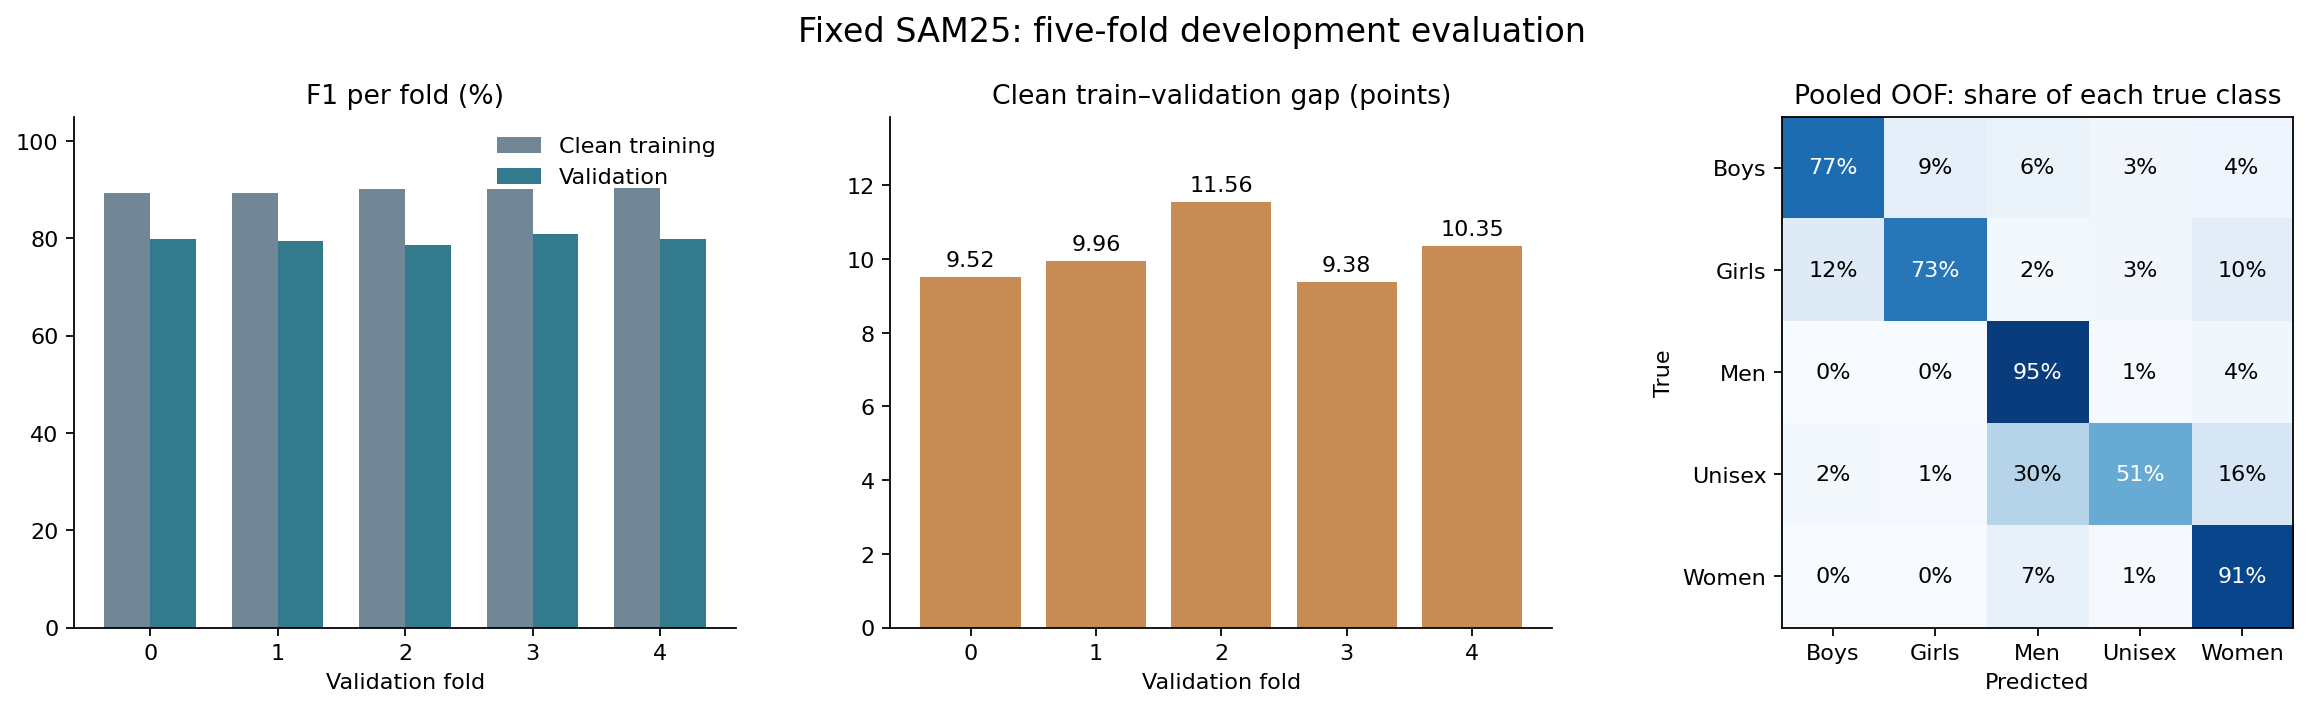

In [4]:
from IPython.display import Image, display

result = run_gender_sam25_cv(
    root=REPO_DIR,
    output_root=DRIVE_TASK_DIR,
    registry_path=DRIVE_REGISTRY,
    registry_mirrors=(LOCAL_REGISTRY,),
    **paths,
)
print("Status:", result["status"])
for row in result["folds"]:
    print(
        "Fold",
        row["fold"],
        "clean training F1:",
        round(row["train_f1"], 4),
        "validation F1:",
        round(row["validation_f1"], 4),
        "gap:",
        round(row["gap"], 4),
    )
for name, scope in result["scopes"].items():
    print(
        name,
        "folds:",
        scope["folds"],
        "validation F1:",
        round(scope["metrics"]["macro_f1"], 4),
        "mean gap:",
        round(scope["mean_clean_gap"], 4),
        "images:",
        scope["metrics"]["support"],
    )
print("Model manifest:", result["model_manifest"])
print("Reports:", result["aggregate_directory"])

display(Image(filename=str(Path(result["aggregate_directory"]) / "fold_summary.png")))

## 5. Review the complete model set

Output: `MyDrive/MLA2/task3/experiments/t3_gender_name_truth_mixup_alpha020_sam005_epoch25_cv/gender`.

- Five run folders each hold `final_epoch.pt`, `config.json`, `normalization.json`, `history.csv`, SAM/MixUp receipts and clean diagnostics.
- `model_manifest.json` lists all five checkpoints, their normalization files, class order and hashes. These are five models trained on different four-fold subsets, not a single model refitted on all development images.
- `aggregate/oof_predictions.csv` contains exactly one prediction per eligible development image, from the model that held out its fold. **Do not average all five models to score these images**: four models trained on each image.
- `aggregate/metrics.json`, `per_class.csv`, `confusion_matrix.csv`, `errors.csv`, `robustness.csv` and `fold_metrics.csv` preserve the full result. `fold_summary.png` shows the fit gaps and class errors. The figure is also saved locally under `results/figures/task3/gender_sam25_cv.png`.
- `cv_summary.json` reports all five folds, the original screen folds (0/4), and the additional folds (1/2/3) separately. `complete_for_review` means training and artifact checks finished; it is not an automatic claim of model superiority.
- Corrected-label and original teacher-label scores are kept separately. The original 19-check screen stays unchanged. There is no five-fold MixUp 0.2 comparison because its existing run covers only folds 0 and 4.

For later predictions on **new images**, use each model's own normalization, average its five class-probability vectors, and choose the largest probability. The OOF score above measures individual held-out fold models, not that five-model ensemble.

No final holdout or teacher-test predictions run here. All five folds are development data, and earlier experiments already used folds 1/2/3. Stop after this run and review the five-fold result before choosing the final model.
